#  Heart Disease Prediction — BRFSS Dataset (CDC)



---
##  Install & Import Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print(' All libraries imported successfully')

 All libraries imported successfully


---
##  Load Dataset


In [53]:
from google.colab import files
uploaded = files.upload()   # heart_disease_health_indicators_BRFSS2015.csv

Saving heart_disease_health_indicators_BRFSS2015.csv to heart_disease_health_indicators_BRFSS2015 (1).csv


In [54]:
# Load the dataset
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (253680, 22)

First 5 rows:


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Features details

In [55]:
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nBasic statistics:')
df.describe()

Column names:
['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data types:
HeartDiseaseorAttack    float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
Diabetes                float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  floa

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.094186,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.296921,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.292087,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.698160,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


---
###  Data Preprocessing & Feature Engineering

In [56]:
# Remove duplicates
print('Before cleaning:', df.shape)
df = df.drop_duplicates()
print('After removing duplicates:', df.shape)

Before cleaning: (253680, 22)
After removing duplicates: (229781, 22)


In [57]:
# Check missing values ---
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.sum() > 0 else ' No missing values found')

Missing values:
 No missing values found


In [58]:
#  Check target column
print('Target column: HeartDiseaseorAttack')
print(df['HeartDiseaseorAttack'].value_counts())
print('\nClass balance (%)')
print((df['HeartDiseaseorAttack'].value_counts(normalize=True) * 100).round(2))

Target column: HeartDiseaseorAttack
HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64

Class balance (%)
HeartDiseaseorAttack
0.0    89.68
1.0    10.32
Name: proportion, dtype: float64


In [59]:
#  Remove invalid BMI values
print('Before BMI filter:', df.shape)
df = df[(df['BMI'] >= 10) & (df['BMI'] <= 80)]
print('After BMI filter :', df.shape)

Before BMI filter: (229781, 22)
After BMI filter : (229502, 22)


In [60]:
#Feature Engineering

def bmi_category(bmi):
    if bmi < 18.5: return 0    # Underweight
    elif bmi < 25: return 1    # Normal
    elif bmi < 30: return 2    # Overweight
    else:          return 3    # Obese

df['BMI_category'] = df['BMI'].apply(bmi_category)

# Health risk score — combines multiple risk factors into one
# Higher = more risk factors present
df['risk_score'] = (
    df['HighBP'] +
    df['HighChol'] +
    df['Smoker'] +
    df['Stroke'] +
    df['Diabetes'] +
    (df['PhysActivity'] == 0).astype(int) +
    (df['GenHlth'] >= 4).astype(int)
)

# Age × High BP interaction (older + high BP = higher risk)
df['age_bp'] = df['Age'] * df['HighBP']

# Age × Diabetes interaction
df['age_diabetes'] = df['Age'] * df['Diabetes']

print(' New features added: BMI_category, risk_score, age_bp, age_diabetes')
print('Dataset shape now:', df.shape)

 New features added: BMI_category, risk_score, age_bp, age_diabetes
Dataset shape now: (229502, 26)


In [61]:
# define features and target

numerical_features = [
    'BMI', 'MentHlth', 'PhysHlth',
    'risk_score', 'age_bp', 'age_diabetes'
]

# Categorical features (no scaling needed)
categorical_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker',
    'Stroke', 'Diabetes', 'PhysActivity', 'Fruits',
    'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex',
    'Age', 'Education', 'Income', 'BMI_category'
]

all_features = numerical_features + categorical_features

X = df[all_features]
y = df['HeartDiseaseorAttack']

print(f'Numerical features  ({len(numerical_features)}):', numerical_features)
print(f'Categorical features ({len(categorical_features)}):', categorical_features)
print(f'\nTotal features: {len(all_features)}')
print(f'\nTarget distribution:')
print(y.value_counts())
print(f'Class balance (%):')
print((y.value_counts(normalize=True) * 100).round(2))

Numerical features  (6): ['BMI', 'MentHlth', 'PhysHlth', 'risk_score', 'age_bp', 'age_diabetes']
Categorical features (19): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_category']

Total features: 25

Target distribution:
HeartDiseaseorAttack
0.0    205805
1.0     23697
Name: count, dtype: int64
Class balance (%):
HeartDiseaseorAttack
0.0    89.67
1.0    10.33
Name: proportion, dtype: float64


---
##  Exploratory Data Analysis (EDA)

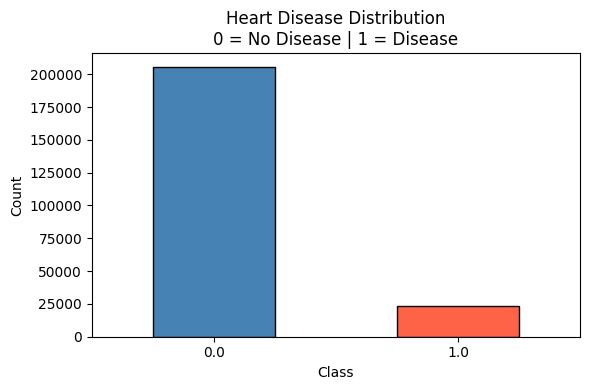

In [62]:
# target class distribution
plt.figure(figsize=(6, 4))
df['HeartDiseaseorAttack'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black'
)
plt.title('Heart Disease Distribution\n0 = No Disease | 1 = Disease')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

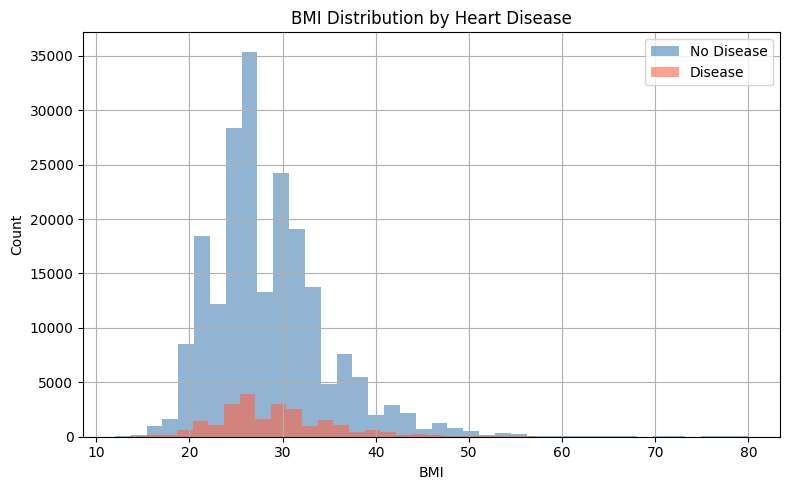

In [63]:
#  BMI distribution by heart disease
plt.figure(figsize=(8, 5))
df[df['HeartDiseaseorAttack'] == 0]['BMI'].hist(
    alpha=0.6, label='No Disease', color='steelblue', bins=40
)
df[df['HeartDiseaseorAttack'] == 1]['BMI'].hist(
    alpha=0.6, label='Disease', color='tomato', bins=40
)
plt.title('BMI Distribution by Heart Disease')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

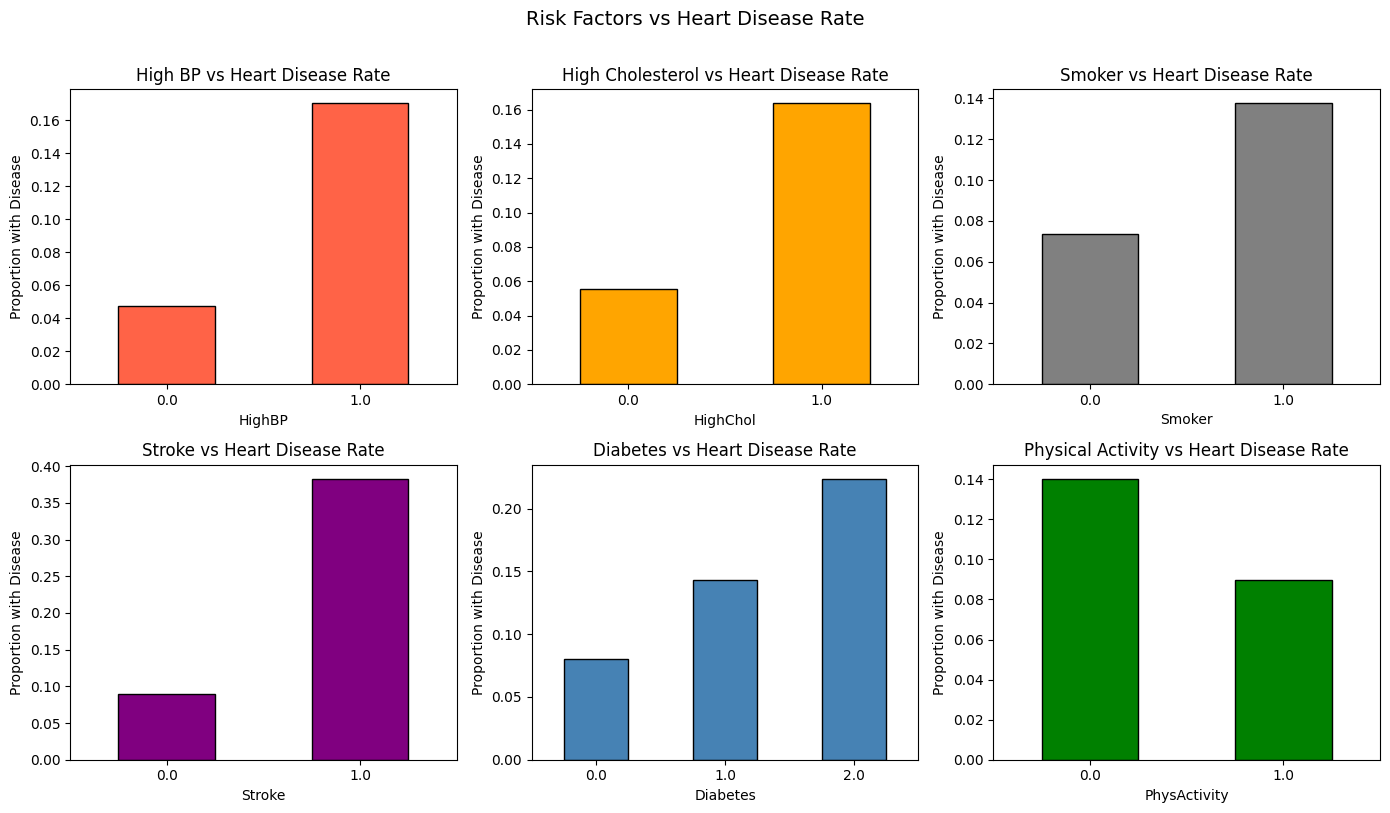

In [64]:
#  Risk factors vs Heart Disease rate
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

risk_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity']
titles    = ['High BP', 'High Cholesterol', 'Smoker', 'Stroke', 'Diabetes', 'Physical Activity']
colors    = ['tomato', 'orange', 'gray', 'purple', 'steelblue', 'green']

for ax, col, title, color in zip(axes.flat, risk_cols, titles, colors):
    df.groupby(col)['HeartDiseaseorAttack'].mean().plot(
        kind='bar', ax=ax, color=color, edgecolor='black'
    )
    ax.set_title(f'{title} vs Heart Disease Rate')
    ax.set_ylabel('Proportion with Disease')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Risk Factors vs Heart Disease Rate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

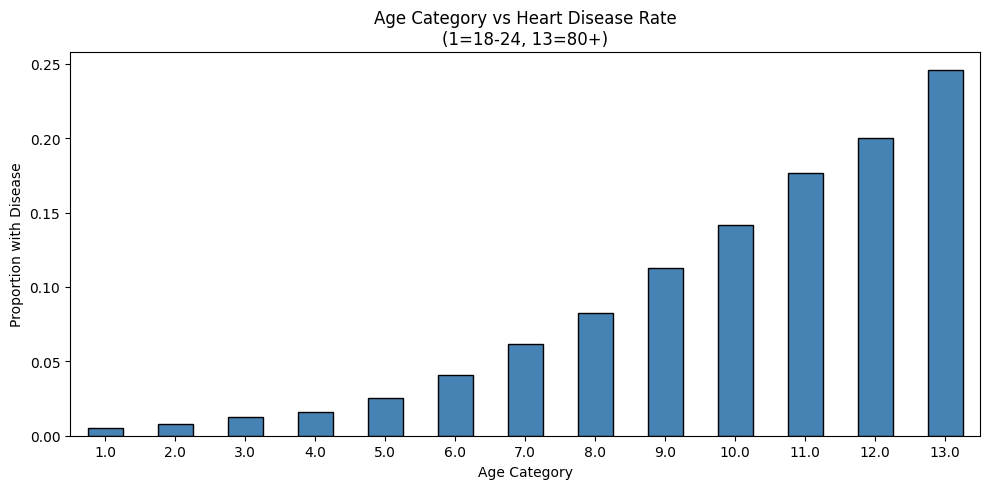

In [65]:
# Age category vs Heart Disease rate
plt.figure(figsize=(10, 5))
df.groupby('Age')['HeartDiseaseorAttack'].mean().plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Age Category vs Heart Disease Rate\n(1=18-24, 13=80+)')
plt.xlabel('Age Category')
plt.ylabel('Proportion with Disease')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

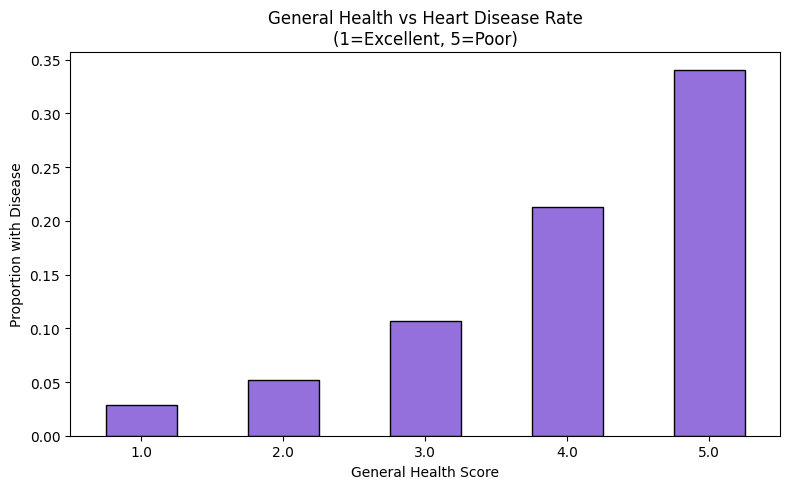

In [66]:
#  General Health vs Heart Disease
plt.figure(figsize=(8, 5))
df.groupby('GenHlth')['HeartDiseaseorAttack'].mean().plot(
    kind='bar', color='mediumpurple', edgecolor='black'
)
plt.title('General Health vs Heart Disease Rate\n(1=Excellent, 5=Poor)')
plt.xlabel('General Health Score')
plt.ylabel('Proportion with Disease')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

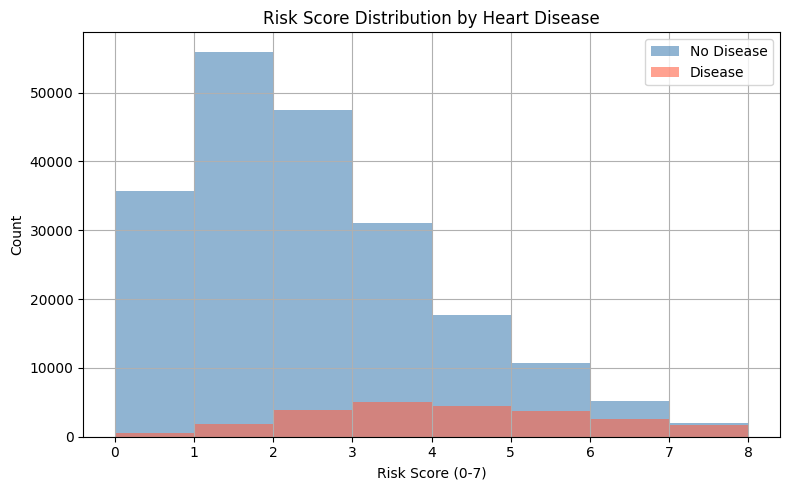

In [67]:
#  Risk Score distribution
plt.figure(figsize=(8, 5))
df[df['HeartDiseaseorAttack'] == 0]['risk_score'].hist(
    alpha=0.6, label='No Disease', color='steelblue', bins=8
)
df[df['HeartDiseaseorAttack'] == 1]['risk_score'].hist(
    alpha=0.6, label='Disease', color='tomato', bins=8
)
plt.title('Risk Score Distribution by Heart Disease')
plt.xlabel('Risk Score (0-7)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

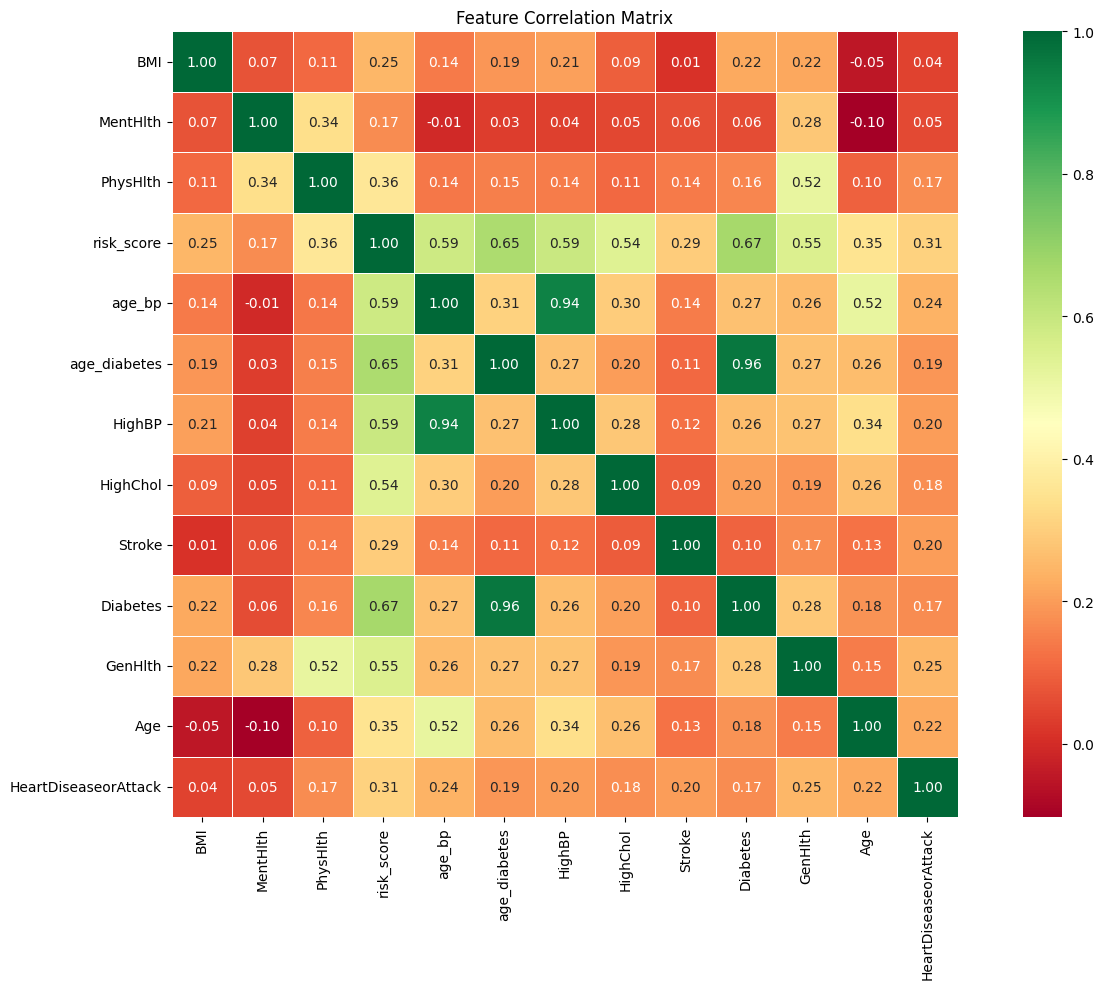

In [68]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_cols = numerical_features + ['HighBP', 'HighChol', 'Stroke',
                                   'Diabetes', 'GenHlth', 'Age',
                                   'HeartDiseaseorAttack']
corr_matrix = df[corr_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    square=True
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
##  Train / Validation / Test Split

**Split:** 70% Training | 15% Validation | 15% Test

In [69]:
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f'Training set   : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation set : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test set       : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

print('\nClass balance in training set:')
print(y_train.value_counts())
print('\nClass percentages:')
print((y_train.value_counts(normalize=True) * 100).round(2))

Training set   : 160,651 samples (70.0%)
Validation set : 34,425 samples (15.0%)
Test set       : 34,426 samples (15.0%)

Class balance in training set:
HeartDiseaseorAttack
0.0    144063
1.0     16588
Name: count, dtype: int64

Class percentages:
HeartDiseaseorAttack
0.0    89.67
1.0    10.33
Name: proportion, dtype: float64


---
##  Feature Scaling

In [70]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_num = scaler.fit_transform(X_train[numerical_features])
X_val_num   = scaler.transform(X_val[numerical_features])
X_test_num  = scaler.transform(X_test[numerical_features])

# Categorical features — no scaling
X_train_cat = X_train[categorical_features].values
X_val_cat   = X_val[categorical_features].values
X_test_cat  = X_test[categorical_features].values

# Combine
X_train_final = np.hstack((X_train_num, X_train_cat))
X_val_final   = np.hstack((X_val_num,   X_val_cat))
X_test_final  = np.hstack((X_test_num,  X_test_cat))

print('X_train shape:', X_train_final.shape)
print('X_val shape  :', X_val_final.shape)
print('X_test shape :', X_test_final.shape)
print(f'Scaler fitted on {scaler.n_features_in_} numerical features')
print('\n Scaling complete — no data leakage')

X_train shape: (160651, 25)
X_val shape  : (34425, 25)
X_test shape : (34426, 25)
Scaler fitted on 6 numerical features

 Scaling complete — no data leakage


---
## Model Training

### KNN model training

Finding best K value for KNN...
This may take 1-2 minutes...
  K= 1  Accuracy=84.96%
  K= 2  Accuracy=89.05%
  K= 3  Accuracy=87.74%
  K= 4  Accuracy=89.26%
  K= 5  Accuracy=88.63%
  K= 6  Accuracy=89.42%
  K= 7  Accuracy=89.12%
  K= 8  Accuracy=89.46%
  K= 9  Accuracy=89.20%
  K=10  Accuracy=89.54%
  K=11  Accuracy=89.43%
  K=12  Accuracy=89.52%
  K=13  Accuracy=89.41%
  K=14  Accuracy=89.54%
  K=15  Accuracy=89.48%
  K=16  Accuracy=89.61%
  K=17  Accuracy=89.55%
  K=18  Accuracy=89.65%
  K=19  Accuracy=89.61%
  K=20  Accuracy=89.68%

 Best K = 20  |  Validation Accuracy = 89.68%


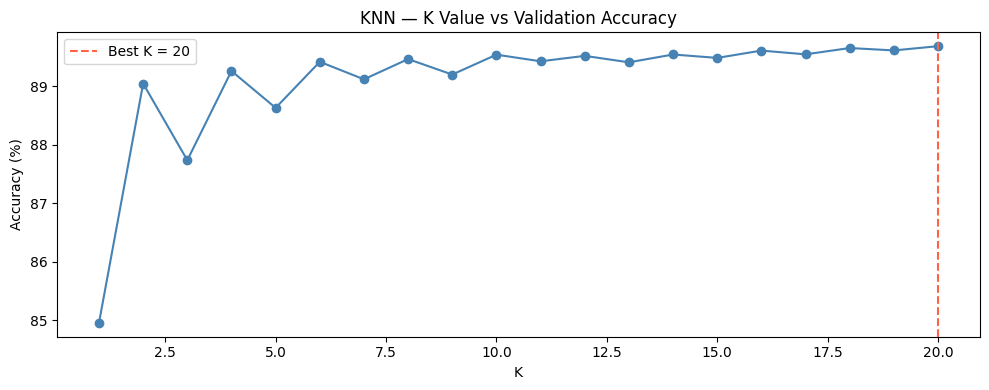

In [71]:

#  KNN: find best k

print('Finding best K value for KNN...')
print('This may take 1-2 minutes...')

accuracy_list = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_final, y_train)
    pred = knn.predict(X_val_final)
    acc  = accuracy_score(y_val, pred)
    accuracy_list.append(acc)
    print(f'  K={k:2d}  Accuracy={acc*100:.2f}%')

best_k = np.argmax(accuracy_list) + 1
print(f'\n Best K = {best_k}  |  Validation Accuracy = {max(accuracy_list)*100:.2f}%')

# Plot
plt.figure(figsize=(10, 4))
plt.plot(k_range, [a*100 for a in accuracy_list], marker='o', color='steelblue')
plt.axvline(x=best_k, color='tomato', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN — K Value vs Validation Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
# Train KNN with best K
knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_model.fit(X_train_final, y_train)
print(f'✅ KNN trained with K = {best_k}')
print(f'   Model expects {knn_model.n_features_in_} features')

✅ KNN trained with K = 20
   Model expects 25 features


### Naive bayes model training

In [73]:
nb_model = GaussianNB()
nb_model.fit(X_train_final, y_train)
print(' Naive Bayes trained')
print(f'   Model expects {nb_model.n_features_in_} features')

 Naive Bayes trained
   Model expects 25 features


### Neural networks model training

In [74]:
print('Training Neural Network...')
print('This may take 3-5 minutes...')

nn_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),  # 4 hidden layers
    activation='relu',                       # ReLU activation
    solver='adam',                           # Adam optimizer
    alpha=0.0001,                            # L2 regularization
    batch_size=512,                          # Mini-batch size
    learning_rate='adaptive',               # Reduces LR when stuck
    learning_rate_init=0.001,               # Starting learning rate
    max_iter=500,                            # Max training epochs
    early_stopping=True,                    # Stop if no improvement
    validation_fraction=0.1,               # 10% of train for early stop
    n_iter_no_change=20,                   # Wait 20 epochs before stopping
    random_state=42,
    verbose=True                            # Show training progress
)

nn_model.fit(X_train_final, y_train)

print(f'\n Neural Network trained')
print(f'   Stopped at iteration: {nn_model.n_iter_}')
print(f'   Model expects {nn_model.n_features_in_} features')

Training Neural Network...
This may take 3-5 minutes...
Iteration 1, loss = 0.27750691
Validation score: 0.899539
Iteration 2, loss = 0.26297914
Validation score: 0.899290
Iteration 3, loss = 0.26038733
Validation score: 0.899851
Iteration 4, loss = 0.25935989
Validation score: 0.899477
Iteration 5, loss = 0.25855379
Validation score: 0.897921
Iteration 6, loss = 0.25814557
Validation score: 0.899913
Iteration 7, loss = 0.25727523
Validation score: 0.899539
Iteration 8, loss = 0.25705779
Validation score: 0.900411
Iteration 9, loss = 0.25662220
Validation score: 0.900100
Iteration 10, loss = 0.25638158
Validation score: 0.898668
Iteration 11, loss = 0.25583499
Validation score: 0.900224
Iteration 12, loss = 0.25539670
Validation score: 0.899664
Iteration 13, loss = 0.25476802
Validation score: 0.899415
Iteration 14, loss = 0.25449663
Validation score: 0.899539
Iteration 15, loss = 0.25453449
Validation score: 0.899477
Iteration 16, loss = 0.25371616
Validation score: 0.899788
Iteration

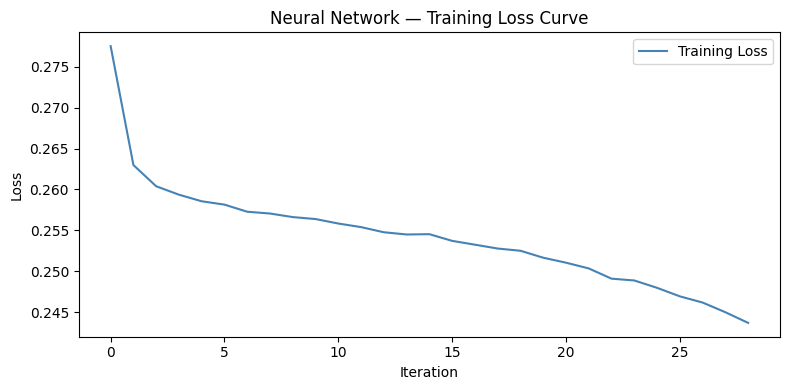

In [75]:
#  Neural Network training loss curve
plt.figure(figsize=(8, 4))
plt.plot(nn_model.loss_curve_, color='steelblue', label='Training Loss')
plt.title('Neural Network — Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## accuracy evaluation

In [76]:

models = {
    'KNN'            : knn_model,
    'Naive Bayes'    : nb_model,
    'Neural Network' : nn_model,
}

print(' all models ready')
print('\nQuick validation accuracy check:')
for name, model in models.items():
    acc = accuracy_score(y_val, model.predict(X_val_final))
    print(f'  {name:20s}: {acc*100:.2f}%')

 all models ready

Quick validation accuracy check:
  KNN                 : 89.68%
  Naive Bayes         : 79.03%
  Neural Network      : 89.93%


---
##  Model Evaluation


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL : KNN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 89.74%
  Precision : 53.35%
  Recall    : 5.15%
  F1 Score  : 9.39%

  Confusion Matrix:
  [[30711   160]
 [ 3372   183]]

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.99      0.95     30871
     Disease       0.53      0.05      0.09      3555

    accuracy                           0.90     34426
   macro avg       0.72      0.52      0.52     34426
weighted avg       0.86      0.90      0.86     34426



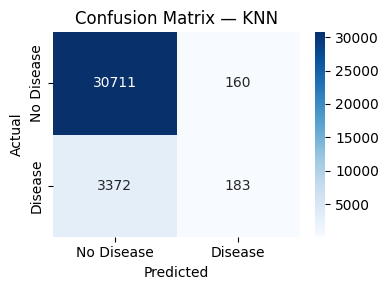


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL : Naive Bayes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 78.65%
  Precision : 26.33%
  Recall    : 59.38%
  F1 Score  : 36.48%

  Confusion Matrix:
  [[24965  5906]
 [ 1444  2111]]

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.95      0.81      0.87     30871
     Disease       0.26      0.59      0.36      3555

    accuracy                           0.79     34426
   macro avg       0.60      0.70      0.62     34426
weighted avg       0.87      0.79      0.82     34426



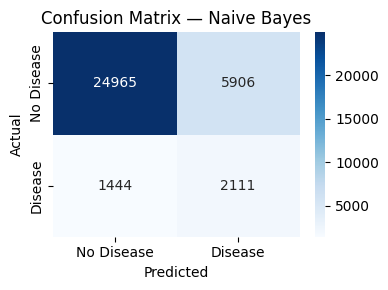


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL : Neural Network
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 89.92%
  Precision : 60.24%
  Recall    : 7.12%
  F1 Score  : 12.73%

  Confusion Matrix:
  [[30704   167]
 [ 3302   253]]

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.99      0.95     30871
     Disease       0.60      0.07      0.13      3555

    accuracy                           0.90     34426
   macro avg       0.75      0.53      0.54     34426
weighted avg       0.87      0.90      0.86     34426



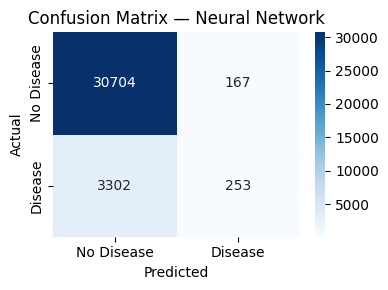

In [77]:
def evaluate_all_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        pred = model.predict(X_test)

        acc  = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec  = recall_score(y_test, pred, zero_division=0)
        f1   = f1_score(y_test, pred, zero_division=0)

        results.append({
            'Model'     : name,
            'Accuracy'  : round(acc  * 100, 2),
            'Precision' : round(prec * 100, 2),
            'Recall'    : round(rec  * 100, 2),
            'F1 Score'  : round(f1   * 100, 2)
        })

        print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
        print(f'  MODEL : {name}')
        print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
        print(f'  Accuracy  : {acc*100:.2f}%')
        print(f'  Precision : {prec*100:.2f}%')
        print(f'  Recall    : {rec*100:.2f}%')
        print(f'  F1 Score  : {f1*100:.2f}%')

        cm = confusion_matrix(y_test, pred)
        print(f'\n  Confusion Matrix:')
        print(f'  {cm}')

        print(f'\n  Classification Report:')
        print(classification_report(
            y_test, pred,
            zero_division=0,
            target_names=['No Disease', 'Disease']
        ))

        # Confusion matrix plot
        plt.figure(figsize=(4, 3))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease']
        )
        plt.title(f'Confusion Matrix — {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results)


results_df = evaluate_all_models(models, X_test_final, y_test)

In [78]:
#  Summary Table
print('\n FINAL RESULTS SUMMARY ')
display(results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True))


 FINAL RESULTS SUMMARY 


,Model,Accuracy,Precision,Recall,F1 Score
0,Neural Network,89.92,60.24,7.12,12.73
1,KNN,89.74,53.35,5.15,9.39
2,Naive Bayes,78.65,26.33,59.38,36.48


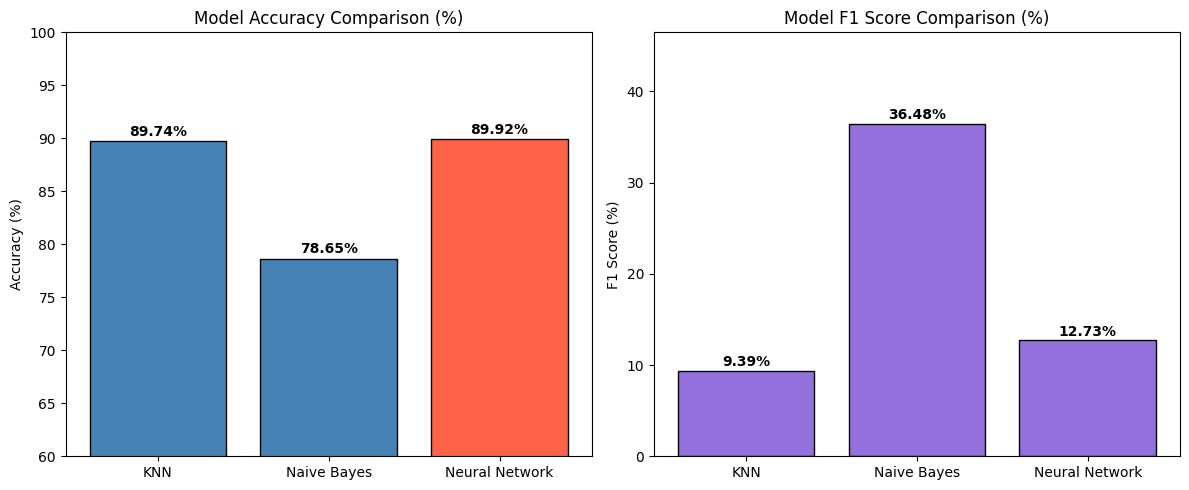

In [79]:


# Comparison Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
bar_colors = ['tomato' if x == max(results_df['Accuracy']) else 'steelblue'
              for x in results_df['Accuracy']]

axes[0].bar(
    results_df['Model'],
    results_df['Accuracy'],
    color=bar_colors,
    edgecolor='black'
)

axes[0].set_title('Model Accuracy Comparison (%)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(60, 100)

for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(
        i, v + 0.5,
        f'{v:.2f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# F1 Score Plot
axes[1].bar(
    results_df['Model'],
    results_df['F1 Score'],
    color='mediumpurple',
    edgecolor='black'
)

axes[1].set_title('Model F1 Score Comparison (%)')
axes[1].set_ylabel('F1 Score (%)')


max_f1 = results_df['F1 Score'].max()
axes[1].set_ylim(0, max_f1 + 10)

for i, v in enumerate(results_df['F1 Score']):
    axes[1].text(
        i, v + 0.5,
        f'{v:.2f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

---
## Best Model Selection & Saving

In [80]:
# find best model by accuracy
best_idx        = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_accuracy   = results_df.loc[best_idx, 'Accuracy']
best_f1         = results_df.loc[best_idx, 'F1 Score']
best_model      = models[best_model_name]

print('=' * 45)
print(f'   BEST MODEL  : {best_model_name}')
print(f'   Accuracy    : {best_accuracy}%')
print(f'  F1 Score    : {best_f1}%')
print(f'   Features    : {best_model.n_features_in_}')
print('=' * 45)

# Save model and scaler
joblib.dump(best_model, 'heart_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print('\nheart_model.pkl saved')
print(' scaler.pkl saved')

   BEST MODEL  : Neural Network
   Accuracy    : 89.92%
  F1 Score    : 12.73%
   Features    : 25

heart_model.pkl saved
 scaler.pkl saved


In [81]:
# Download saved files to your computer
from google.colab import files
files.download('heart_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
##  Predict on New Patient


In [82]:
def predict_patient(model, scaler, patient_input):
    """
    Predict heart disease risk for a new patient.
    Must match the same features used during training.
    """
    # Compute derived features (same as Section 3.5)
    bmi = patient_input['BMI']

    def bmi_category(b):
        if b < 18.5: return 0
        elif b < 25: return 1
        elif b < 30: return 2
        else:        return 3

    bmi_cat   = bmi_category(bmi)
    risk_score = (
        patient_input['HighBP'] +
        patient_input['HighChol'] +
        patient_input['Smoker'] +
        patient_input['Stroke'] +
        patient_input['Diabetes'] +
        (1 if patient_input['PhysActivity'] == 0 else 0) +
        (1 if patient_input['GenHlth'] >= 4 else 0)
    )
    age_bp       = patient_input['Age'] * patient_input['HighBP']
    age_diabetes = patient_input['Age'] * patient_input['Diabetes']

    # Numerical values — must match numerical_features order
    # ['BMI', 'MentHlth', 'PhysHlth', 'risk_score', 'age_bp', 'age_diabetes']
    numerical_vals = [[
        bmi,
        patient_input['MentHlth'],
        patient_input['PhysHlth'],
        risk_score,
        age_bp,
        age_diabetes
    ]]

    # Categorical values — must match categorical_features order
    # ['HighBP','HighChol','CholCheck','Smoker','Stroke','Diabetes',
    #  'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare',
    #  'NoDocbcCost','GenHlth','DiffWalk','Sex','Age','Education','Income','BMI_category']
    categorical_vals = [[
        patient_input['HighBP'],
        patient_input['HighChol'],
        patient_input['CholCheck'],
        patient_input['Smoker'],
        patient_input['Stroke'],
        patient_input['Diabetes'],
        patient_input['PhysActivity'],
        patient_input['Fruits'],
        patient_input['Veggies'],
        patient_input['HvyAlcoholConsump'],
        patient_input['AnyHealthcare'],
        patient_input['NoDocbcCost'],
        patient_input['GenHlth'],
        patient_input['DiffWalk'],
        patient_input['Sex'],
        patient_input['Age'],
        patient_input['Education'],
        patient_input['Income'],
        bmi_cat
    ]]

    num_scaled  = scaler.transform(numerical_vals)
    final_input = np.hstack((num_scaled, categorical_vals))

    prediction  = model.predict(final_input)[0]
    probability = model.predict_proba(final_input)[0] if hasattr(model, 'predict_proba') else None

    print('=' * 45)
    print('  PATIENT INPUT:')
    for k, v in patient_input.items():
        print(f'    {k:22s}: {v}')
    print(f'    {"BMI Category":22s}: {bmi_cat}  (0=Under, 1=Normal, 2=Over, 3=Obese)')
    print(f'    {"Risk Score":22s}: {risk_score}/7')
    print()
    print('  PREDICTION:')
    if prediction == 1:
        print(' HEART DISEASE RISK DETECTED')
    else:
        print('  No Heart Disease Risk')
    if probability is not None:
        print(f'    Confidence : {max(probability)*100:.1f}%')
        print(f'    Risk Prob  : {probability[1]*100:.1f}%')
    print('=' * 45)


print("\nEnter Patient Details:\n")

sample_patient = {
    'HighBP'            : int(input('High Blood Pressure (0=No, 1=Yes): ')),
    'HighChol'          : int(input('High Cholesterol (0=No, 1=Yes): ')),
    'CholCheck'         : int(input('Cholesterol Check in last 5 years (0=No, 1=Yes): ')),
    'BMI'               : float(input('BMI: ')),
    'Smoker'            : int(input('Smoker (0=No, 1=Yes): ')),
    'Stroke'            : int(input('Stroke History (0=No, 1=Yes): ')),
    'Diabetes'          : int(input('Diabetes (0=No, 1=Yes): ')),
    'PhysActivity'      : int(input('Physical Activity (0=No, 1=Yes): ')),
    'Fruits'            : int(input('Consumes Fruits Daily (0=No, 1=Yes): ')),
    'Veggies'           : int(input('Consumes Vegetables Daily (0=No, 1=Yes): ')),
    'HvyAlcoholConsump' : int(input('Heavy Alcohol Consumption (0=No, 1=Yes): ')),
    'AnyHealthcare'     : int(input('Has Healthcare Coverage (0=No, 1=Yes): ')),
    'NoDocbcCost'       : int(input('Could Not See Doctor Due To Cost (0=No, 1=Yes): ')),
    'GenHlth'           : int(input('General Health (1=Excellent ... 5=Poor): ')),
    'MentHlth'          : int(input('Bad Mental Health Days (0-30): ')),
    'PhysHlth'          : int(input('Bad Physical Health Days (0-30): ')),
    'DiffWalk'          : int(input('Difficulty Walking (0=No, 1=Yes): ')),
    'Sex'               : int(input('Sex (0=Female, 1=Male): ')),
    'Age'               : int(input('Age Category (1-13): ')),
    'Education'         : int(input('Education Level (1-6): ')),
    'Income'            : int(input('Income Category (1-8): '))
}

predict_patient(best_model, scaler, sample_patient)


Enter Patient Details:

High Blood Pressure (0=No, 1=Yes): 0
High Cholesterol (0=No, 1=Yes): 1
Cholesterol Check in last 5 years (0=No, 1=Yes): 0
BMI: 20
Smoker (0=No, 1=Yes): 0
Stroke History (0=No, 1=Yes): 1
Diabetes (0=No, 1=Yes): 0
Physical Activity (0=No, 1=Yes): 0
Consumes Fruits Daily (0=No, 1=Yes): 1
Consumes Vegetables Daily (0=No, 1=Yes): 0
Heavy Alcohol Consumption (0=No, 1=Yes): 0
Has Healthcare Coverage (0=No, 1=Yes): 0
Could Not See Doctor Due To Cost (0=No, 1=Yes): 0
General Health (1=Excellent ... 5=Poor): 5
Bad Mental Health Days (0-30): 19
Bad Physical Health Days (0-30): 17
Difficulty Walking (0=No, 1=Yes): 0
Sex (0=Female, 1=Male): 0
Age Category (1-13): 6
Education Level (1-6): 5
Income Category (1-8): 7
  PATIENT INPUT:
    HighBP                : 0
    HighChol              : 1
    CholCheck             : 0
    BMI                   : 20.0
    Smoker                : 0
    Stroke                : 1
    Diabetes              : 0
    PhysActivity          : 0
    

---
## Feature Importance



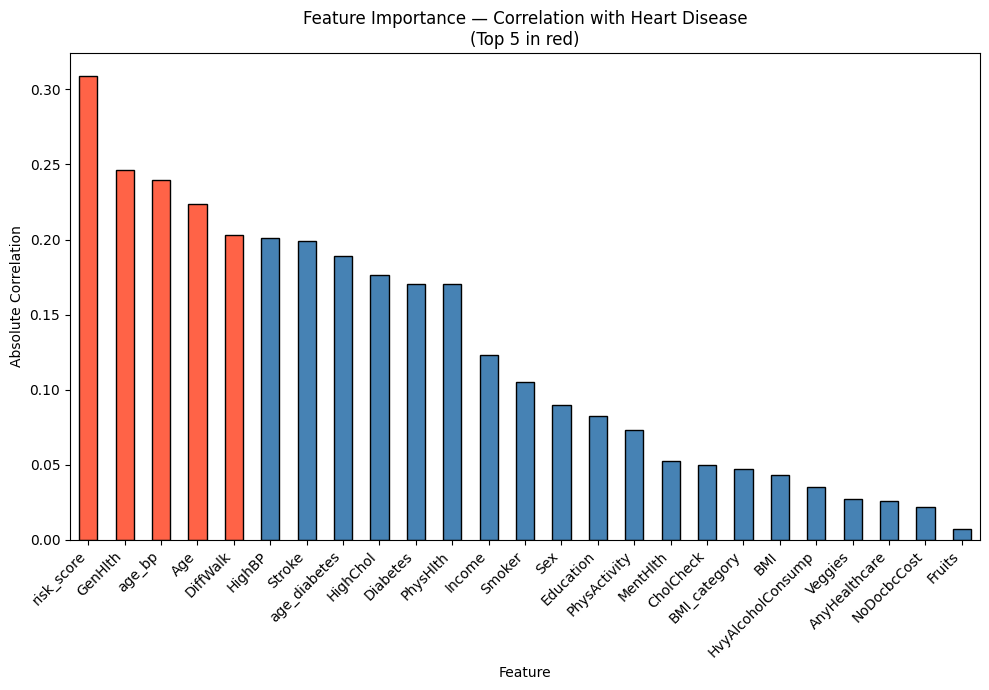


 Top 10 most important features:
   1. risk_score             — correlation: 0.3087
   2. GenHlth                — correlation: 0.2464
   3. age_bp                 — correlation: 0.2394
   4. Age                    — correlation: 0.2236
   5. DiffWalk               — correlation: 0.2027
   6. HighBP                 — correlation: 0.2012
   7. Stroke                 — correlation: 0.1988
   8. age_diabetes           — correlation: 0.1891
   9. HighChol               — correlation: 0.1764
  10. Diabetes               — correlation: 0.1707


In [83]:
# Feature importance via correlation with target
feature_names = numerical_features + categorical_features

corr_with_target = df[feature_names + ['HeartDiseaseorAttack']].corr()['HeartDiseaseorAttack']
corr_with_target = corr_with_target.drop('HeartDiseaseorAttack').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr_with_target.plot(
    kind='bar',
    color=['tomato' if i < 5 else 'steelblue' for i in range(len(corr_with_target))],
    edgecolor='black'
)
plt.title('Feature Importance — Correlation with Heart Disease\n(Top 5 in red)')
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n Top 10 most important features:')
for i, (feat, val) in enumerate(corr_with_target.head(10).items()):
    print(f'  {i+1:2d}. {feat:22s} — correlation: {val:.4f}')

In [84]:
# Final summary printout
print('\n' + '='*50)
print('         FINAL PROJECT SUMMARY')
print('='*50)
print(f'  Dataset        : BRFSS 2015 (CDC)')
print(f'  Total samples  : {len(df):,}')
print(f'  Total features : {len(all_features)}')
print(f'  Training size  : {len(X_train_final):,} (85%)')
print(f'  Test size      : {len(X_test_final):,} (7.5%)')
print()
print('  MODEL RESULTS:')
for _, row in results_df.sort_values('Accuracy', ascending=False).iterrows():
    marker = '' if row['Model'] == best_model_name else '  '
    print(f'  {marker} {row["Model"]:20s}: Accuracy={row["Accuracy"]}%  F1={row["F1 Score"]}%')
print()
print(f'  Best Model     : {best_model_name}')
print(f'  Best Accuracy  : {best_accuracy}%')
print('='*50)


         FINAL PROJECT SUMMARY
  Dataset        : BRFSS 2015 (CDC)
  Total samples  : 229,502
  Total features : 25
  Training size  : 160,651 (85%)
  Test size      : 34,426 (7.5%)

  MODEL RESULTS:
   Neural Network      : Accuracy=89.92%  F1=12.73%
     KNN                 : Accuracy=89.74%  F1=9.39%
     Naive Bayes         : Accuracy=78.65%  F1=36.48%

  Best Model     : Neural Network
  Best Accuracy  : 89.92%
